# PINN experiment notebook

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch import nn

from data_generation import get_initial_condition, get_time_sampling
from net import PINN
from train_test import train_loop

sns.set()

In [2]:
# get the initial conditions, and the training input for the Net
initial_conditions = get_initial_condition()
input = get_time_sampling(max_time=2.0, num_samples=1000)
print(initial_conditions)
print(input.shape)

{'time-positon': (0, 0)}
torch.Size([1000, 1])


In [3]:
# get model
model = PINN()
print(model)

PINN(
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=1, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=1, bias=True)
  )
)


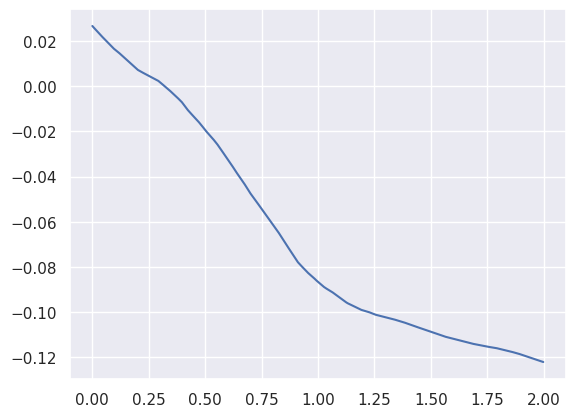

In [4]:
# see initial result for model output
output = model(input)
# As the output is one-dimensional, we can easily visualize it with respect to the input
plt.figure()
plt.plot(input.detach().numpy(), output.detach().numpy())
plt.show()

In [10]:
# define the optimizer
learning_rate = 1e-3
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
train_loop(input, model, optimizer)

None


/home/ssuarez/tutorials/pytorch_tutorial/PINN/train_test.py:30: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/pytorch/pull/30531 for more informations. (Triggered internally at aten/src/ATen/core/TensorBody.h:489.)
  print("========================")
/home/ssuarez/tutorials/pytorch_tutorial/PINN/train_test.py:32: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access t

TypeError: unsupported operand type(s) for +: 'NoneType' and 'Tensor'

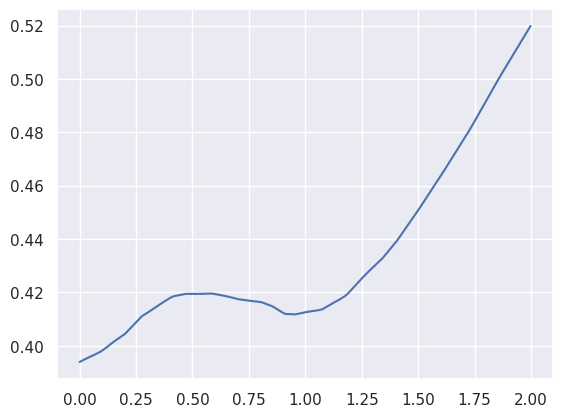

In [6]:
output = model(input)
plt.figure()
plt.plot(input.detach().numpy(), output.detach().numpy())
plt.show()

Epoch 1
----------------------------
Loss: 0.103340 [   10/  100]
Loss: 0.128443 [   30/  100]
Loss: 0.138210 [   50/  100]
Loss: 0.074410 [   70/  100]
Loss: 0.100727 [   90/  100]
Loss: 0.072186 [  110/  100]
Loss: 0.076467 [  130/  100]
Loss: 0.065292 [  150/  100]
Loss: 0.099722 [  170/  100]
Loss: 0.127367 [  190/  100]
Loss: 0.078541 [  210/  100]
Loss: 0.074286 [  230/  100]
Loss: 0.092423 [  250/  100]
Loss: 0.049766 [  270/  100]
Loss: 0.092293 [  290/  100]
Loss: 0.144904 [  310/  100]
Loss: 0.073377 [  330/  100]
Loss: 0.124096 [  350/  100]
Loss: 0.080495 [  370/  100]
Loss: 0.057009 [  390/  100]
Loss: 0.048991 [  410/  100]
Loss: 0.119192 [  430/  100]
Loss: 0.069217 [  450/  100]
Loss: 0.090888 [  470/  100]
Loss: 0.078041 [  490/  100]
Loss: 0.068612 [  510/  100]
Loss: 0.090794 [  530/  100]
Loss: 0.088695 [  550/  100]
Loss: 0.074252 [  570/  100]
Loss: 0.087294 [  590/  100]
Loss: 0.104049 [  610/  100]
Loss: 0.064411 [  630/  100]
Loss: 0.091431 [  650/  100]
Loss: 

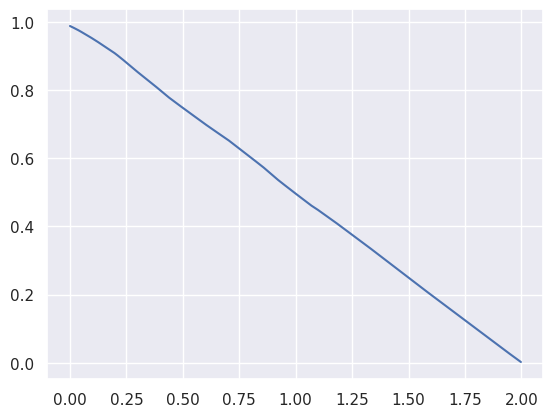

In [7]:
epochs = 1000
for t in range(epochs):
    print(f"Epoch {t+1}\n----------------------------")
    train_loop(input, model, optimizer)
output = model(input)
plt.figure()
plt.plot(input.detach().numpy(), output.detach().numpy())
plt.show()

demora pila en ajustar bien esto, holy shit

In [8]:
# compute the derivative of the model
x = input.sort().values
x.requires_grad = True
y = model(x)
Y = torch.sum(y)
Y.backward()


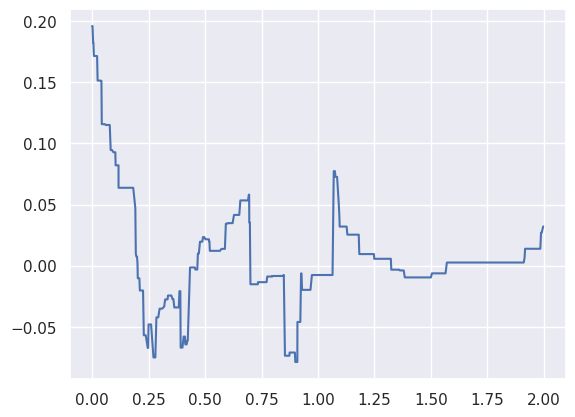

In [11]:
plt.figure()
plt.plot(x.detach().numpy(), x.grad.detach().numpy() + 0.5)
plt.show()

/home/ssuarez/tutorials/pytorch_tutorial/.env/lib/python3.9/site-packages/torch/autograd/__init__.py:394: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 11050). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at ../c10/cuda/CUDAFunctions.cpp:108.)
  result = Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch [0/10000], Loss: 1.0673860311508179
Epoch [1000/10000], Loss: 2.4656967070768587e-05
Epoch [2000/10000], Loss: 1.300273765991733e-06
Epoch [3000/10000], Loss: 1.6716303434805013e-06
Epoch [4000/10000], Loss: 6.378129000950139e-06
Epoch [5000/10000], Loss: 9.573567467668909e-07
Epoch [6000/10000], Loss: 1.5861849078646628e-06
Epoch [7000/10000], Loss: 5.205970410315786e-07
Epoch [8000/10000], Loss: 4.2352164086878474e-07
Epoch [9000/10000], Loss: 1.051655999617651e-06


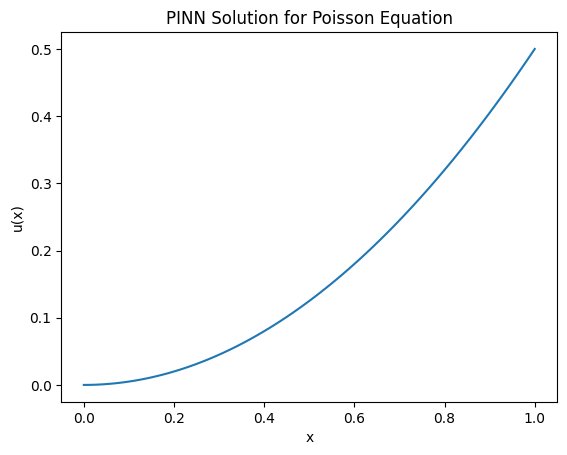

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

# Define the PINN model
class PINN(nn.Module):
    def __init__(self):
        super(PINN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 50),   # Input layer with 1 feature
            nn.Tanh(),
            nn.Linear(50, 50),  # Hidden layer
            nn.Tanh(),
            nn.Linear(50, 1)    # Output layer for u(x)
        )

    def forward(self, x):
        return self.net(x)

# Define the Poisson equation loss function
def poisson_loss(model, x):
    u = model(x)
    # create_graph 
    #   -> creates a graph with relevant derivatives for higher order computations
    #   -> just as in the operations below        
    # retain_graph -> retains computationl graph, defailts to create_graph
    # gradients with respect to other inputs are not computed, and will not add up
    # on sucessive calls.
    # Why the [0] on the gradients? the return is a tuple of tensors. Each tensor is the gradient of
    # one input (sequential) to one output (there can be multiple outputs, and the return onject)
    # would be a multidimensional tuple
    # why the grad_outputs, they are used to scale up or down the ouputted gradient.
    # additional functionality, not so usefuel here. The thing that is here is essentially
    # the same as having the default value for grad_outputs.
    u_x = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x, grad_outputs=torch.ones_like(u_x), create_graph=True)[0]
    f = (u_xx - 1.0)**2  # Poisson equation: u_xx = 1
    x_0 = torch.tensor([0.0], requires_grad=True)
    u_0 = model(x_0)
    initial_conditions = (u_0 - 0)**2
    # should YES need the `create_graph`,
    # for the .backward call that will be used later in the optimization
    u_x_0 = torch.autograd.grad(u_0, x_0, grad_outputs=torch.ones_like(u_0), create_graph=True)[0]
    initial_conditions_der = (u_x_0 - 0)**2
    return torch.mean(f) + torch.mean(initial_conditions) + torch.mean(initial_conditions_der)

# Training data
x = torch.rand(100, 1)  # Randomly sampled points in [0, 1]
x.requires_grad = True

# Create PINN model
model = PINN()

optimizer = optim.Adam(params=model.parameters(), lr=0.001)

# Training loop
epochs = 10000
for epoch in range(epochs):
    optimizer.zero_grad()
    
    # Compute the loss
    loss = poisson_loss(model, x)
    
    # Backpropagation
    loss.backward()
    optimizer.step()
    
    if epoch % 1000 == 0:
        print(f"Epoch [{epoch}/{epochs}], Loss: {loss.item()}")

# Test the model
x_test = torch.linspace(0, 1, 100).reshape(-1, 1)
u_test = model(x_test)

# Plot the results
import matplotlib.pyplot as plt
plt.plot(x_test.detach().numpy(), u_test.detach().numpy())
plt.xlabel('x')
plt.ylabel('u(x)')
plt.title('PINN Solution for Poisson Equation')
plt.show()